# Entrega 1 · Preparación de los datos
### Predicción de renuncias de empleados (IBM HR Analytics)

M71V/M72V 02 · Implementación de Modelos de Aprendizaje Automático · UBA · **Giovanni Raffo** · [github.com/gioaqp/attrition-uba](https://github.com/gioaqp/attrition-uba)

La primera celda solo actúa en Google Colab: descarga el proyecto e instala lo necesario.

In [1]:
import sys, os
if "google.colab" in sys.modules:
    if not os.path.exists("/content/attrition-uba"):
        !git clone -q https://github.com/gioaqp/attrition-uba.git /content/attrition-uba
    %cd /content/attrition-uba/notebooks
    !pip install -q sweetviz scikit-learn==1.9.1

## 1. El problema

La renuncia voluntaria de un empleado cuesta meses de salario: reclutar, capacitar y recuperar productividad. Queremos anticiparla: para cada empleado, la **probabilidad de que renuncie**, para que Recursos Humanos priorice con quién conversar antes. Es una clasificación binaria: renuncia o se queda.

Los datos son los asignados por el profesor: *IBM HR Analytics Employee Attrition* (Kaggle), 1.470 empleados y 35 columnas, datos ficticios creados por IBM. Solo el 16 % renuncia: el problema está **desbalanceado**, y eso condiciona qué métricas sirven y cómo se entrena.

## 2. Los datos

Se leen tal como los publicó el profesor. El archivo trae una marca de codificación (BOM) que se quita con `utf-8-sig`.

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/WA_Fn-UseC_-HR-Employee-Attrition.csv", encoding="utf-8-sig")
print("Empleados:", df.shape[0], "  Columnas:", df.shape[1])
df.head()

Empleados: 1470   Columnas: 35


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


Tipo de dato, cantidad de valores distintos y un ejemplo por columna. Sirve para detectar columnas sospechosas: un solo valor, o un valor distinto por empleado.

In [3]:
pd.DataFrame({"tipo": df.dtypes, "valores_distintos": df.nunique(), "ejemplo": df.iloc[0]})

,tipo,valores_distintos,ejemplo
Age,int64,43,41
Attrition,object,2,Yes
BusinessTravel,object,3,Travel_Rarely
DailyRate,int64,886,1102
Department,object,3,Sales
DistanceFromHome,int64,29,1
Education,int64,5,2
EducationField,object,6,Life Sciences
EmployeeCount,int64,1,1
EmployeeNumber,int64,1470,1


## 3. Calidad: faltantes, duplicados y valores extremos

Primero se verifica que no falte nada ni haya empleados repetidos.

In [4]:
print("Celdas vacías:", df.isnull().sum().sum())
print("Filas duplicadas:", df.duplicated().sum())

Celdas vacías: 0
Filas duplicadas: 0


**Resultado:** no hay faltantes ni duplicados; no hay nada que imputar ni borrar.

**Valores extremos.** Un director gana mucho más que un técnico y alguien puede tener 40 años de carrera: son empleados reales, no errores. **Decisión:** se conservan; el modelo, con las variables escaladas, los tolera.

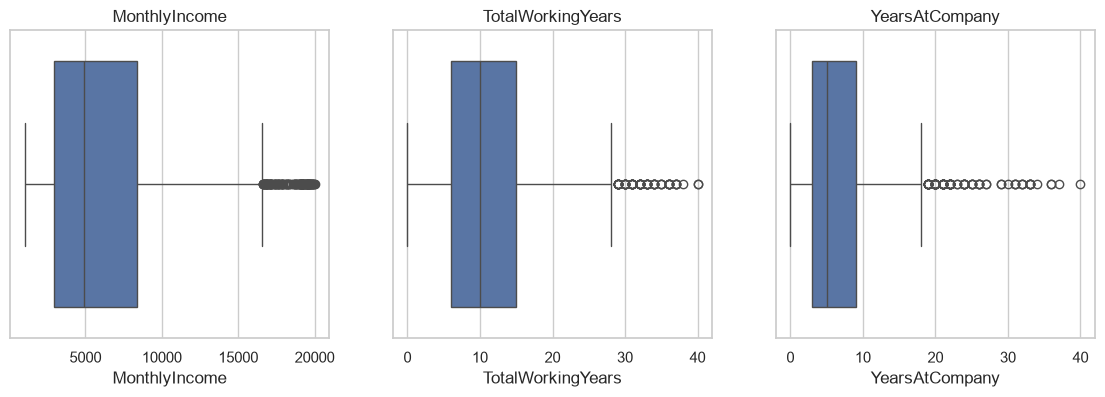

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

fig, ejes = plt.subplots(1, 3, figsize=(14, 4))
for eje, col in zip(ejes, ["MonthlyIncome", "TotalWorkingYears", "YearsAtCompany"]):
    sns.boxplot(x=df[col], ax=eje)
    eje.set_title(col)
plt.show()

## 4. Columnas que no aportan

Con código se buscan columnas **constantes** (varianza cero: no distinguen a nadie) e **identificadores** (un valor por empleado: describen al legajo, no a la persona, y el modelo podría memorizarlos).

In [6]:
constantes = df.columns[df.nunique() == 1].tolist()
identificadores = df.columns[df.nunique() == len(df)].tolist()
print("Constantes:", constantes)
print("Identificadores:", identificadores)

df = df.drop(columns=constantes + identificadores)
print("Quedan", df.shape[1], "columnas")
print("Columnas con solo dos valores:", df.columns[df.nunique() == 2].tolist())
print(df["PerformanceRating"].value_counts())

Constantes: ['EmployeeCount', 'Over18', 'StandardHours']
Identificadores: ['EmployeeNumber']
Quedan 31 columnas
Columnas con solo dos valores: ['Attrition', 'Gender', 'OverTime', 'PerformanceRating']
PerformanceRating
3    1244
4     226
Name: count, dtype: int64


**Decisión:** se eliminan las tres constantes y el número de legajo. `PerformanceRating` es casi constante (85 % con el mismo valor) pero se conserva: todavía distingue empleados y un modelo regularizado no se perjudica.

## 5. Tipos de variables

Las categóricas (texto) se convierten en columnas de sí/no; las numéricas se llevan a una misma escala. **Decisión:** las nueve escalas de encuesta (satisfacción, nivel educativo, etc.) se tratan como números, porque el orden es información. No se crean variables nuevas: el dataset ya trae las derivadas útiles.

In [7]:
objetivo = "Attrition"
categoricas = df.drop(columns=objetivo).select_dtypes("object").columns.tolist()
numericas = df.drop(columns=objetivo).select_dtypes("number").columns.tolist()

print("Categóricas:", len(categoricas))
for c in categoricas:
    print("  ", c, "->", sorted(df[c].unique()))
print("Numéricas:", len(numericas))
print("  ", numericas)

Categóricas: 7
   BusinessTravel -> ['Non-Travel', 'Travel_Frequently', 'Travel_Rarely']
   Department -> ['Human Resources', 'Research & Development', 'Sales']
   EducationField -> ['Human Resources', 'Life Sciences', 'Marketing', 'Medical', 'Other', 'Technical Degree']
   Gender -> ['Female', 'Male']
   JobRole -> ['Healthcare Representative', 'Human Resources', 'Laboratory Technician', 'Manager', 'Manufacturing Director', 'Research Director', 'Research Scientist', 'Sales Executive', 'Sales Representative']
   MaritalStatus -> ['Divorced', 'Married', 'Single']
   OverTime -> ['No', 'Yes']
Numéricas: 23
   ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurren

## 6. Exploración

Cuatro preguntas de Recursos Humanos: ¿cuántos renuncian? ¿pesan las horas extra? ¿qué puestos son críticos? ¿el ingreso hace diferencia?

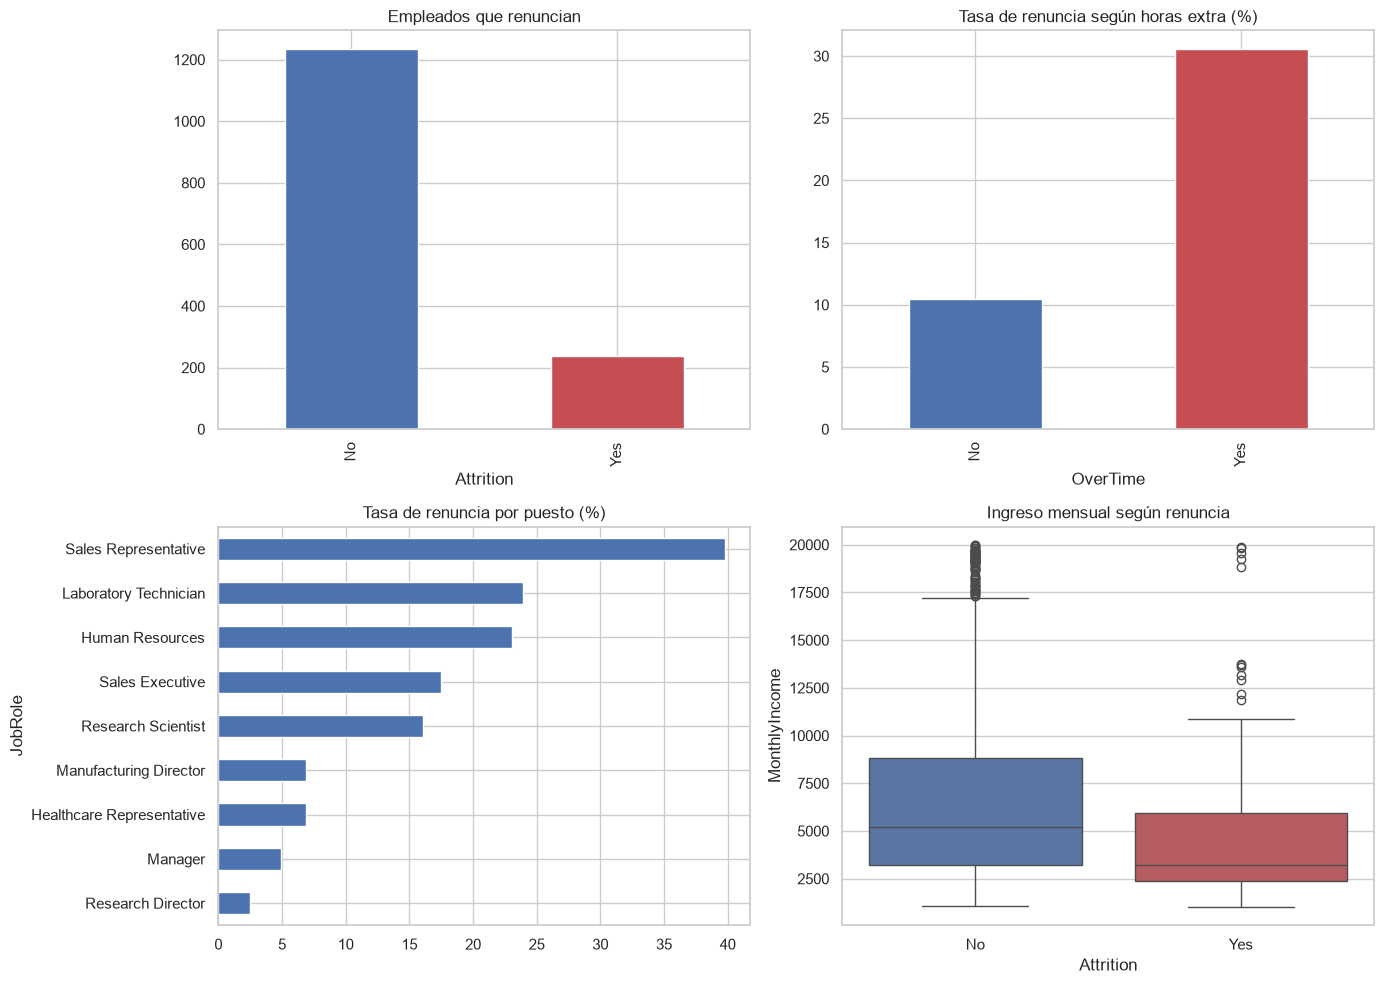

Tasa de renuncia con horas extra: 30.5 %  sin horas extra: 10.4 %
Puesto con más renuncias: Sales Representative 39.8 %
Ingreso mensual mediano:
Attrition
No     5204.0
Yes    3202.0
Name: MonthlyIncome, dtype: float64


In [8]:
fig, ejes = plt.subplots(2, 2, figsize=(14, 10))

df[objetivo].value_counts().plot.bar(ax=ejes[0, 0], color=["#4C72B0", "#C44E52"], title="Empleados que renuncian")

tasa_ot = df.groupby("OverTime")[objetivo].apply(lambda s: (s == "Yes").mean() * 100)
tasa_ot.plot.bar(ax=ejes[0, 1], color=["#4C72B0", "#C44E52"], title="Tasa de renuncia según horas extra (%)")

tasa_puesto = df.groupby("JobRole")[objetivo].apply(lambda s: (s == "Yes").mean() * 100).sort_values()
tasa_puesto.plot.barh(ax=ejes[1, 0], title="Tasa de renuncia por puesto (%)")

sns.boxplot(data=df, x=objetivo, y="MonthlyIncome", hue=objetivo, order=["No", "Yes"], palette={"No": "#4C72B0", "Yes": "#C44E52"}, legend=False, ax=ejes[1, 1])
ejes[1, 1].set_title("Ingreso mensual según renuncia")
plt.tight_layout()
plt.show()

print("Tasa de renuncia con horas extra:", round(tasa_ot["Yes"], 1), "%  sin horas extra:", round(tasa_ot["No"], 1), "%")
print("Puesto con más renuncias:", tasa_puesto.idxmax(), round(tasa_puesto.max(), 1), "%")
print("Ingreso mensual mediano:")
print(df.groupby(objetivo)["MonthlyIncome"].median())

**Lectura:** renuncia uno de cada seis. Con horas extra, casi tres veces más. Los representantes de ventas son el puesto más crítico. Quien renuncia gana menos.

### Correlación entre numéricas

Si dos variables son casi la misma cosa, el modelo no puede separar sus efectos.

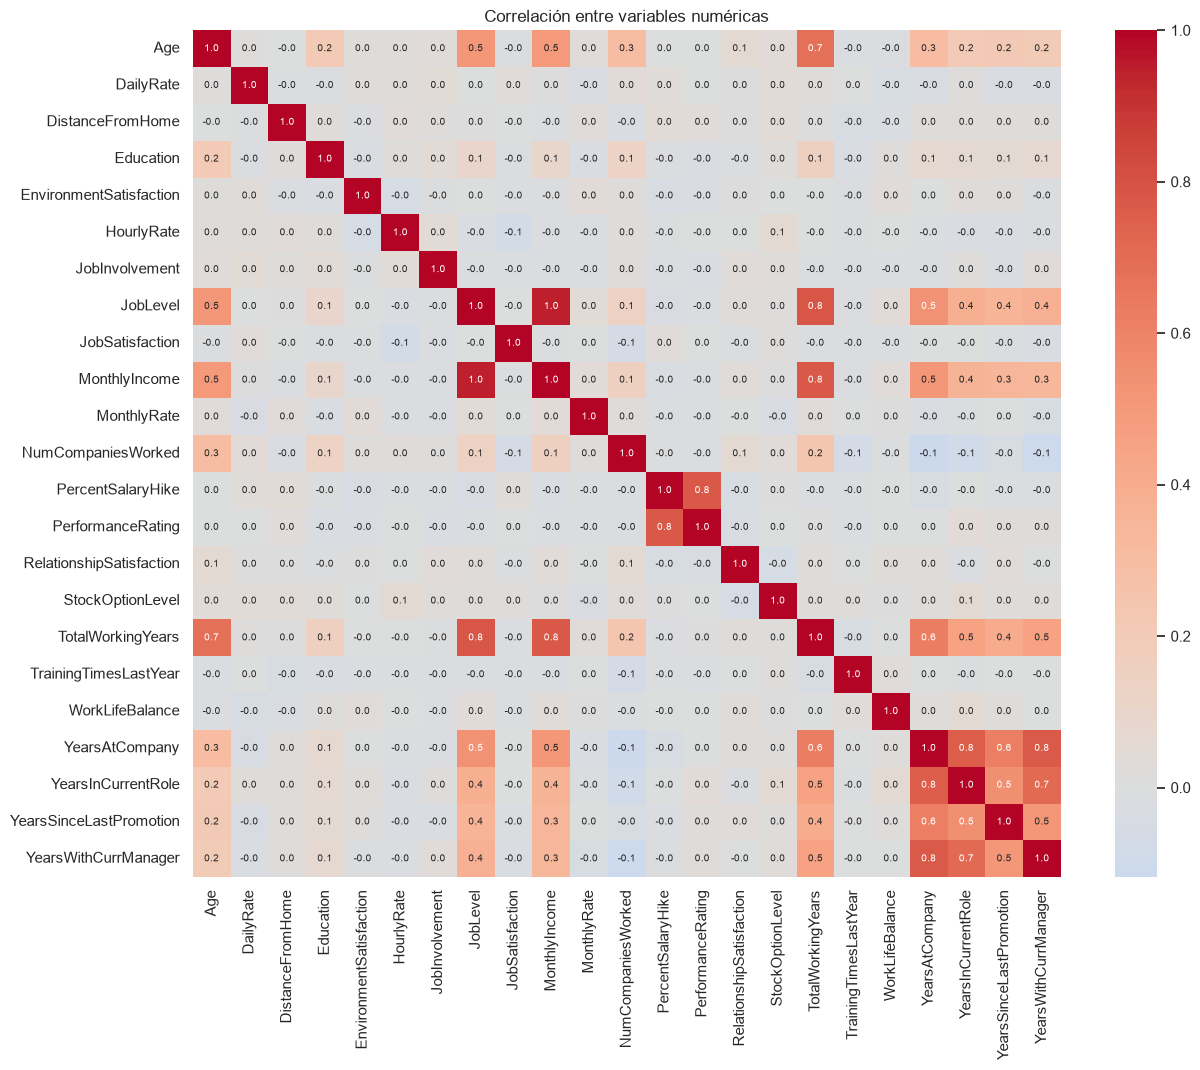

In [9]:
corr = df[numericas].corr()
plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".1f", annot_kws={"size": 7})
plt.title("Correlación entre variables numéricas")
plt.show()

**Lectura:** las variables de trayectoria (años en la empresa, en el rol, con el jefe, de carrera) se mueven en bloque; nivel jerárquico e ingreso van casi pegados.

### Multicolinealidad

Regla: con correlación de 0,9 o más se conserva una sola variable; entre 0,7 y 0,9 se conservan ambas, porque el modelo regularizado las tolera.

In [10]:
pares = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
print("Correlación de 0.9 o más:")
print(pares[pares.abs() >= 0.9].round(2))
print("\nEntre 0.7 y 0.9:")
print(pares[(pares.abs() >= 0.7) & (pares.abs() < 0.9)].sort_values(ascending=False).round(2))

df = df.drop(columns="JobLevel")
numericas.remove("JobLevel")

Correlación de 0.9 o más:
JobLevel  MonthlyIncome    0.95
dtype: float64

Entre 0.7 y 0.9:
JobLevel            TotalWorkingYears       0.78
PercentSalaryHike   PerformanceRating       0.77
MonthlyIncome       TotalWorkingYears       0.77
YearsAtCompany      YearsWithCurrManager    0.77
                    YearsInCurrentRole      0.76
YearsInCurrentRole  YearsWithCurrManager    0.71
dtype: float64


**Decisión:** se elimina `JobLevel`, casi idéntica al ingreso (0,95); el ingreso es más accionable para Recursos Humanos.

### Reporte automático (Sweetviz)

Como en clase, un informe automático de cada variable contra la renuncia. Queda en `reports/eda_sweetviz.html`.

In [11]:
import logging, warnings
os.environ["TQDM_DISABLE"] = "1"
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
import sweetviz as sv

df_reporte = df.drop(columns=objetivo).assign(Renuncia=(df[objetivo] == "Yes").astype(int))
sv.analyze(df_reporte, target_feat="Renuncia").show_html("../reports/eda_sweetviz.html", open_browser=False, layout="vertical")

Report ../reports/eda_sweetviz.html was generated.


## 7. Grupo de examen

Apartamos el 20 % de los empleados **antes de tocar nada**, con la misma proporción de renuncias. El modelo se evalúa con ellos una sola vez, al final. Así el escalado y la codificación se aprenden solo del 80 % y no hay *data leakage*.

In [12]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=objetivo)
y = (df[objetivo] == "Yes").astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Entrenamiento:", len(X_train), "empleados,", y_train.sum(), "renuncias")
print("Examen:", len(X_test), "empleados,", y_test.sum(), "renuncias")

Entrenamiento: 1176 empleados, 190 renuncias
Examen: 294 empleados, 47 renuncias


Son 47 renuncias en el examen, pocas. Por eso el ajuste fino del modelo se hace con validación cruzada dentro del 80 %.

## 8. Receta de preparación

Toda la preparación en un solo objeto: escalar las numéricas y codificar las categóricas. Se ajusta solo con el grupo de entrenamiento y se aplica igual a cualquier empleado. En la Entrega 2 se une al modelo; en la Entrega 3 viaja a la API. `handle_unknown="ignore"`: una categoría nueva no rompe el modelo.

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preparacion = ColumnTransformer([
    ("num", StandardScaler(), numericas),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False), categoricas),
])
preparacion.fit(X_train)

nombres = preparacion.get_feature_names_out()
print("Variables de entrada:", X_train.shape[1], "  Columnas preparadas:", len(nombres))
pd.DataFrame(preparacion.transform(X_train.head(1)), columns=nombres).T.round(2)

Variables de entrada: 29   Columnas preparadas: 48


,0
num__Age,1.09
num__DailyRate,1.05
num__DistanceFromHome,-0.90
num__Education,1.06
num__EnvironmentSatisfaction,-0.66
num__HourlyRate,-0.91
num__JobInvolvement,1.80
num__JobSatisfaction,-0.65
num__MonthlyIncome,2.03
num__MonthlyRate,0.93


**Resultado:** 29 variables se convierten en 48 columnas. Arriba, un empleado ya preparado.

### Balance de clases

Solo el 16 % renuncia. **Decisión:** en vez de inventar empleados sintéticos (SMOTE), el modelo pesará más los errores sobre quienes renuncian (`class_weight="balanced"`). Mismo objetivo, sin datos artificiales.

In [14]:
from sklearn.utils.class_weight import compute_class_weight

pesos = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train)
print("Peso se queda:", round(pesos[0], 2), "  Peso renuncia:", round(pesos[1], 2))

Peso se queda: 0.6   Peso renuncia: 3.09


Una renuncia mal predicha pesa unas cinco veces más: la proporción real entre ambos grupos.

### Transformaciones

El objetivo es sí/no: no se transforma. Algunas numéricas están sesgadas (abajo). **Decisión:** no transformarlas, para mantener las unidades originales y leer los pesos del modelo directo.

In [15]:
print(X_train[numericas].skew().sort_values(ascending=False).head(6).round(2))

YearsSinceLastPromotion    1.97
PerformanceRating          1.88
YearsAtCompany             1.73
MonthlyIncome              1.33
TotalWorkingYears          1.10
NumCompaniesWorked         1.00
dtype: float64


### Componentes principales (PCA)

Comprime muchas variables en pocas componentes combinadas. Se analiza para ver si vale la pena.

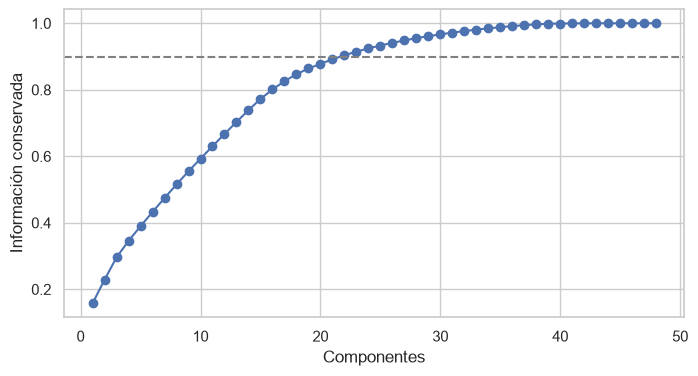

Componentes para el 80 %: 16   para el 90 %: 22


In [16]:
%matplotlib inline
sns.set_theme(style="whitegrid")
from sklearn.decomposition import PCA

X_train_prep = preparacion.transform(X_train)
acumulada = np.cumsum(PCA().fit(X_train_prep).explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(acumulada) + 1), acumulada, marker="o")
plt.axhline(0.9, color="gray", linestyle="--")
plt.xlabel("Componentes")
plt.ylabel("Información conservada")
plt.show()
print("Componentes para el 80 %:", np.argmax(acumulada >= 0.8) + 1, "  para el 90 %:", np.argmax(acumulada >= 0.9) + 1)

**Decisión:** no usar PCA. Hacen falta 22 de 48 componentes para el 90 % de la información, y se perdería la lectura directa de cada variable, que es lo que Recursos Humanos necesita.

### Ranking de variables

Información mutua: cuánto ayuda cada variable a anticipar la renuncia, sin entrenar ningún modelo.

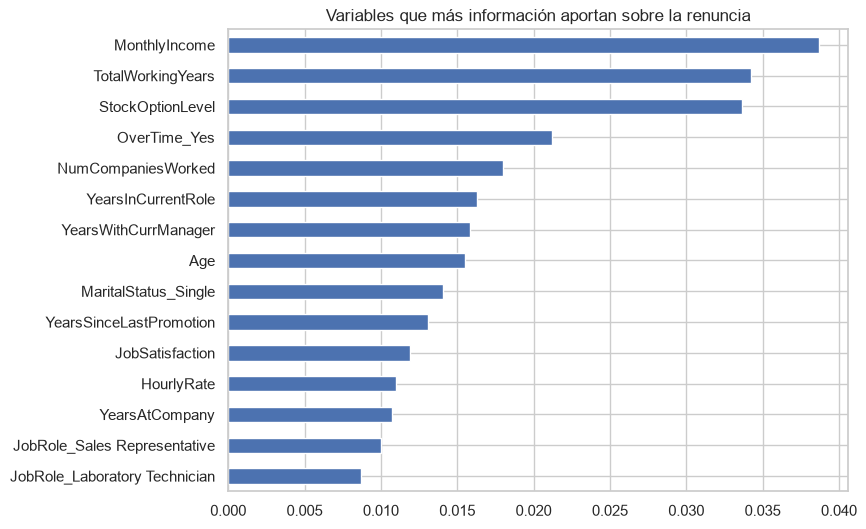

In [17]:
from sklearn.feature_selection import mutual_info_classif

discretas = np.array([not n.startswith("num__") for n in nombres])
mi = mutual_info_classif(X_train_prep, y_train, discrete_features=discretas, random_state=42)
ranking = pd.Series(mi, index=[n.split("__")[1] for n in nombres]).sort_values()

ranking.tail(15).plot.barh(figsize=(8, 6), title="Variables que más información aportan sobre la renuncia")
plt.show()

**Lectura:** ingreso, antigüedad, opciones sobre acciones y horas extra encabezan el ranking. Es una guía, no una selección: el modelo recibe todas las variables.

### Dataset final

Se entregan en `data/procesado/` el dataset limpio y los grupos de entrenamiento y examen ya preparados.

In [18]:
os.makedirs("../data/procesado", exist_ok=True)
df.to_csv("../data/procesado/attrition_limpio.csv", index=False)

train_prep = pd.DataFrame(X_train_prep, columns=nombres).assign(Renuncia=y_train.values)
test_prep = pd.DataFrame(preparacion.transform(X_test), columns=nombres).assign(Renuncia=y_test.values)
train_prep.to_csv("../data/procesado/train_preparado.csv", index=False)
test_prep.to_csv("../data/procesado/test_preparado.csv", index=False)
print("Limpio:", df.shape, " Entrenamiento:", train_prep.shape, " Examen:", test_prep.shape)

Limpio: (1470, 30)  Entrenamiento: (1176, 49)  Examen: (294, 49)


## 9. Baseline

Predecir siempre "se queda", sin aprender nada. Medido con validación cruzada dentro del entrenamiento; el examen no se toca.

In [19]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

validacion = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
baseline = DummyClassifier(strategy="most_frequent")
res = cross_validate(baseline, X_train, y_train, cv=validacion, scoring=["accuracy", "recall", "roc_auc"])

print("Accuracy:", round(res["test_accuracy"].mean(), 3))
print("Recall:", round(res["test_recall"].mean(), 3))
print("ROC-AUC:", round(res["test_roc_auc"].mean(), 2))

Accuracy: 0.838
Recall: 0.0
ROC-AUC: 0.5


**Lectura:** acierta el 84 % sin mirar un dato, pero no detecta ninguna renuncia (recall 0) y su ROC-AUC de 0,50 es el azar. Por eso la exactitud no sirve acá: en la Entrega 2 se miran ROC-AUC, recall y precisión.

## 10. Cierre

| Punto de la Primera Asignación | Decisión |
|---|---|
| Análisis exploratorio | Cuatro gráficos, correlación y reporte Sweetviz |
| Faltantes | No hay; verificado |
| Outliers | Se conservan: son empleados reales |
| Nuevas variables / tipos | No se crean; escalas de encuesta como números |
| Encoding | One-hot de las 7 categóricas, dentro de la receta |
| Balance | Pesos de clase, sin datos sintéticos |
| Normalización | Escalado estándar de las numéricas |
| Transformaciones | No; se mantienen las unidades originales |
| Multicolinealidad | Se elimina `JobLevel` (0,95 con el ingreso) |
| Baja varianza | Se eliminan las constantes; `PerformanceRating` se conserva |
| PCA | Analizado; no se usa |
| Ranking de variables | Información mutua, top 15 |
| Dataset final | `data/procesado/` |

**Sigue:** Entrega 2, el modelo.